In [1]:
import sys

sys.path.append("../")
sys.path.append("./")

from matplotlib import pyplot as plt
import numpy as np

from trading_information.distributions import BetaMixture, Uniform
from trading_information.virtual_values import VirtualValues
from trading_information.mechanism import Mechanism, MechanismTrapz
from trading_information.hyperopt import HyperOpt

from scipy import stats

dist = Uniform(0, 1)

In [6]:
dist = Uniform(0, 1)

dist = Uniform(0, 1)  # uniform
# dist = stats.expon()
#dist = BetaMixture((8, 60), (30, 30), (0.5, 0.5))  # bimodal
#dist = BetaMixture([80], [20], [1])  # low
#dist = BetaMixture([20], [80], [1])  # high

mechanism = Mechanism(num_types=1000, dist=dist)
mechanism_trapz = MechanismTrapz(num_intervals=1000, dist=dist)
types = mechanism.types



tau = 1000
tau0 = tau1 = tau
prob_state0 = 0
tj = prob_state0
threshold_type = 0.5

(allocations,
transfers,
externalities,
multiplier,
avg_transfer,
avg_externality,
objective) = mechanism.solve(tau, prob_state0, threshold_type)

(incs, 
 allocations_trapz,
transfers_trapz,
externalities_trapz,
multiplier_trapz,
avg_transfer_trapz,
avg_externality_trapz,
objective_trapz) = mechanism_trapz.solve(tau, prob_state0, threshold_type)



SLACK 0.0


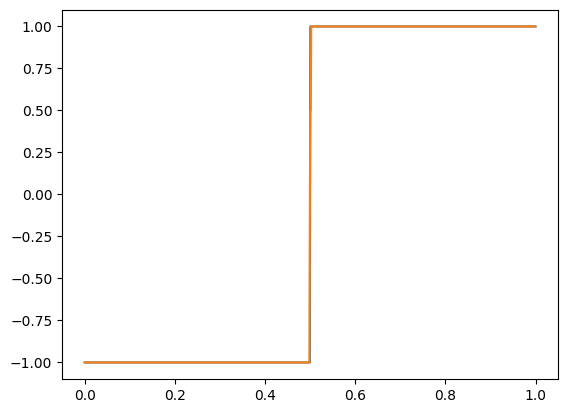

In [7]:
fig, ax = plt.subplots()
ax.plot(mechanism.types, allocations)
ax.plot(mechanism_trapz.midpoints, allocations_trapz)

In [8]:
avg_transfer, avg_transfer_trapz

(array(0.000501), array(0.000997))

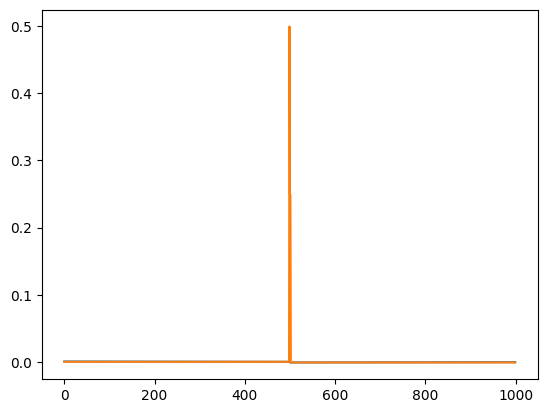

In [9]:
plt.plot(transfers)
plt.plot(transfers_trapz)

In [21]:
from scipy.integrate import trapezoid

trapezoid(y=transfers * dist.pdf(mechanism.types), x=mechanism.types)

0.13579990127061117

In [22]:
trapezoid(y=transfers_trapz * dist.pdf(mechanism_trapz.midpoints), x=mechanism_trapz.midpoints)

0.1354518858155884

In [ ]:
avg_externality, avg_externality_trapz

NameError: name 'avg_externality' is not defined

In [ ]:
np.mean(allocations_trapz)

NameError: name 'np' is not defined

In [ ]:
incs[mechanism_trapz.midpoints <= threshold_type]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [2]:
incs[mechanism_trapz.midpoints >= threshold_type]

NameError: name 'incs' is not defined

In [9]:
np.mean(allocations_trapz)

0.0

In [27]:
incs[5] = 1
incs[6] = 0

In [28]:
incs[mechanism_trapz.midpoints >= threshold_type]

array([1., 0., 0., 0., 0.])

In [29]:
np.sum(incs * np.arange(mechanism_trapz.num_intervals, 0, -1))

11.0

In [31]:
(incs * np.arange(mechanism_trapz.num_intervals, 0, -1))

array([0., 0., 0., 0., 6., 5., 0., 0., 0., 0.])

In [32]:
mechanism_trapz.num_intervals

10

In [24]:
np.arange(mechanism_trapz.num_intervals, -1, -1).shape

(1001,)

In [34]:
mechanism_trapz.num_intervals

10